<a href="https://colab.research.google.com/github/changx2-source/changx2.github.io/blob/main/CS215Final_Xylia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, I analyze Apple’s stock price from 2023 to early 2025. I chose Apple because it is one of the most well known technology companies, and its stock price is often discussed around major product events, especially iPhone launches. My goal is to understand the general trend in Apple’s stock price, examine the changes around major events, and use moving averages to smooth out daily price changes.

The main questions I want to answer are:

How did Apple’s closing price change from 2023 to 2025?

What do the 20-day and 50-day moving averages show about Apple’s stock trend?

Did Apple’s stock price noticeably change around major iPhone launch events?

In [1]:
# Download data from yahoo using yfinance
!pip install yfinance pandas matplotlib

The dataset was collected from Yahoo Finance using the yfinance Python package. It includes Apple’s daily stock data from January 1, 2023 to January 1, 2025. The main variable I focus on is the closing price, which represents the stock price at the end of each trading day. I also use the date index to study how the price changes over time.

In [2]:
# import data
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

ticker = "AAPL"

df = yf.download(ticker, start="2023-01-01", end="2025-01-01")
df.head()

/tmp/ipykernel_12474/1244729728.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982712,128.715409,122.097730,128.105761,112117500
2023-01-04,124.251175,126.512793,122.992538,124.772329,89113600
2023-01-05,122.933556,125.637661,122.677900,125.008343,80962700
2023-01-06,127.456802,128.115619,122.805744,123.907056,87754700
2023-01-09,127.977928,131.183532,127.722273,128.292595,70790800


Before making visualizations, I checked the structure of the dataset using commands df.head(), df.shape, df.info(), and df.describe(). This helped me understand the number of observations, the available columns, and the basic summary statistics. I then created two new variables: a 20-day moving average and a 50-day moving average. These moving averages help smooth out daily price changes and make the longer-term trend easier to see.

In [4]:
# Look at the data
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2023-01-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   502 non-null    float64
 1   (High, AAPL)    502 non-null    float64
 2   (Low, AAPL)     502 non-null    float64
 3   (Open, AAPL)    502 non-null    float64
 4   (Volume, AAPL)  502 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,502.000000,502.000000,502.000000,502.000000,5.020000e+02
mean,187.896248,189.387128,186.136365,187.626463,5.816095e+07
std,28.062066,28.203120,27.821258,28.056515,2.512372e+07
min,122.933556,125.637661,122.097730,123.907056,2.323470e+07
25%,169.785667,171.405382,168.538165,169.863031,4.495800e+07
50%,183.135078,184.472870,181.520304,183.078692,5.250285e+07
75%,212.437260,215.194188,210.137204,212.657851,6.489808e+07
max,257.375580,258.448740,255.994420,256.550862,3.186799e+08


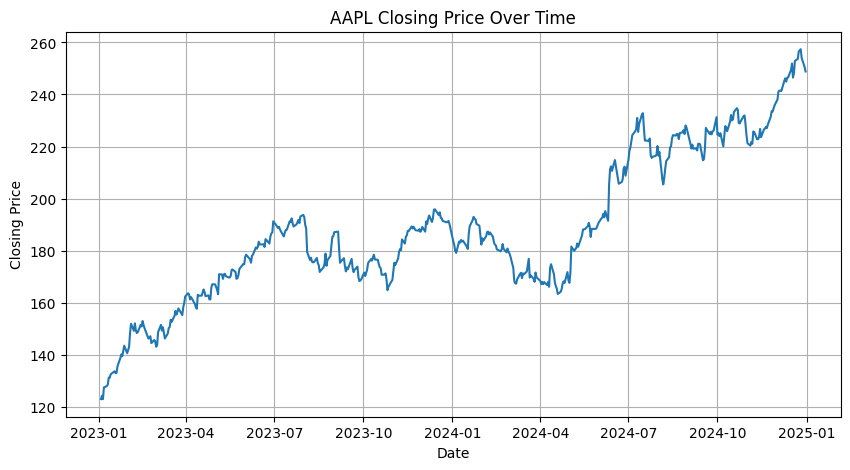

In [5]:
# Line graph for apple stock from 2023 to 2025
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

I plotted Apple’s closing price over time to get a general view of the stock trend above. This graph helps show whether the stock price mostly increased, decreased, or stayed stable during the time period.

From the graph, Apple’s stock price generally increased from 2023 to early 2025. There were some periods of decline and fluctuation, but the overall direction was upward. The increase became especially clear after mid-2024, when the stock price rose more strongly.

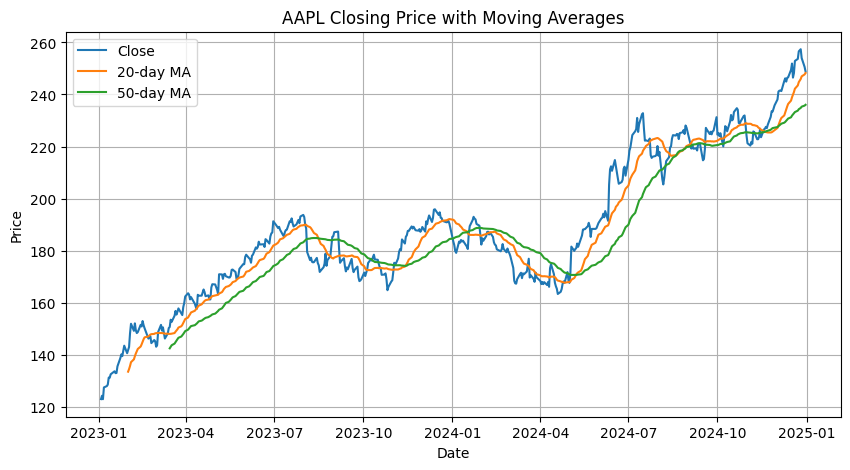

In [6]:

df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

## Set the figure size
plt.figure(figsize=(10,5))
# Plot closing price and moving averages
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA20"], label="20-day MA")
plt.plot(df.index, df["MA50"], label="50-day MA")
plt.title(f"{ticker} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

For this graph, I used moving averages to better understand the stock trend. A moving average smooths out short term changes by averaging prices over a certain number of days. I used a 20-day moving average to show shorter-term movement and a 50-day moving average to show a smoother, longer-term trend.

The 20 day moving average follows the closing price more closely, while the 50 day moving average changes more slowly. When the closing price and the 20 day moving average are above the 50 day moving average, it suggests stronger upward momentum. In this graph, Apple’s stock shows a clearer upward trend after mid-2024.

Because Apple is closely connected to its product launches, I also looked at stock price changes around major iPhone events. Instead of only looking at the overall trend, this part focuses on shorter time windows around specific launch dates. This helps me see whether the stock price moved up or down near those events.

In [7]:
# Events that happened during this time
events = {
    "Apple Vision Pro announced": "2023-06-05",
    "iPhone 15 event": "2023-09-12",
    "Apple Q2 earnings 2024": "2024-05-02",
    "iPhone 16 event": "2024-09-09"
}

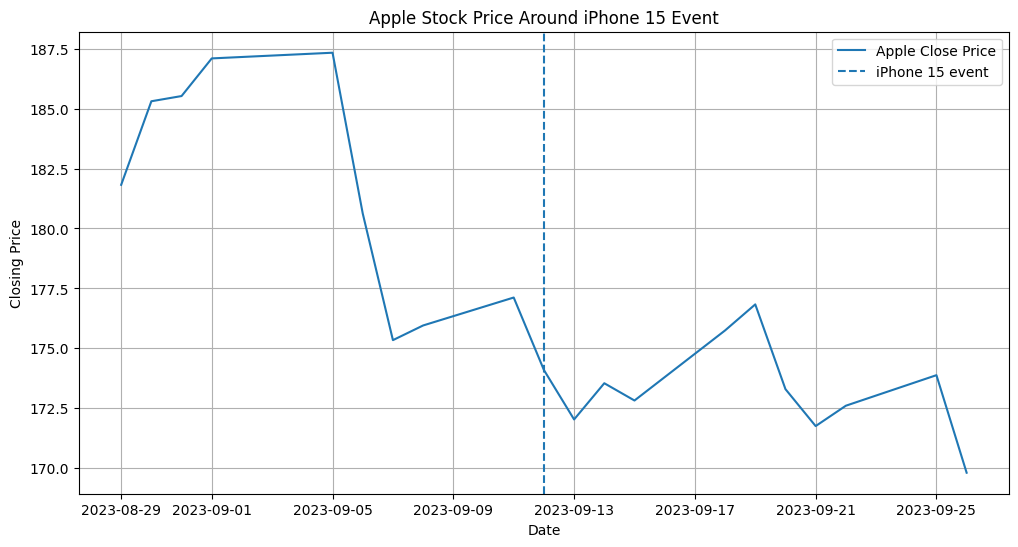

In [8]:
# To see if the event has effect the market
event_name = "iPhone 15 event"
event_date = "2023-09-12"

window = df.loc["2023-08-29":"2023-09-26"]

plt.figure(figsize=(12,6))
plt.plot(window.index, window["Close"], label="Apple Close Price")
plt.axvline(pd.to_datetime(event_date), linestyle="--", label=event_name)

plt.title("Apple Stock Price Around iPhone 15 Event")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

The graph shows Apple’s stock price around the iPhone 15 event. The vertical line marks the event date. Around this event, the stock price did not show a strong increase immediately after the launch. Instead, the price moved downward in the short term. This suggests that the iPhone event alone may not have caused an immediate positive stock market reaction.

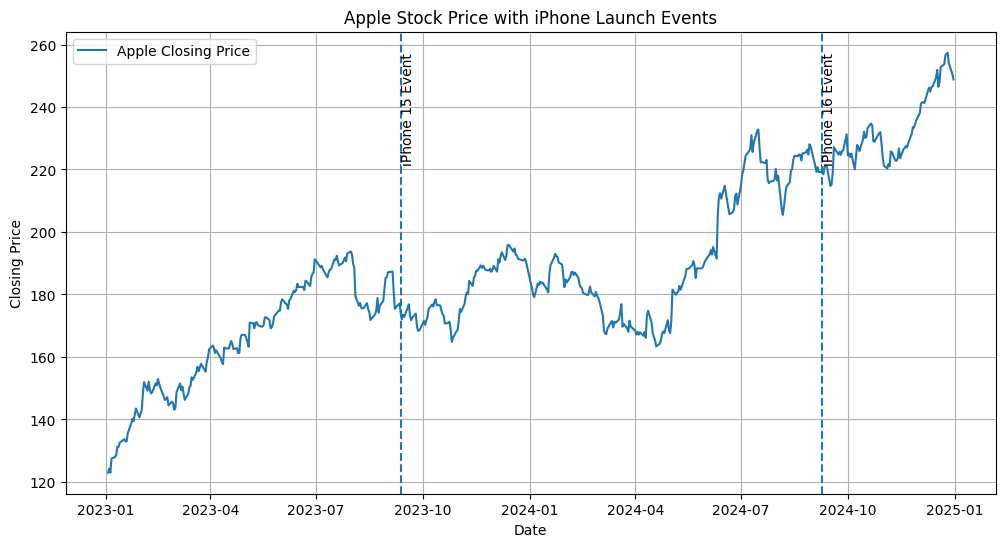

In [10]:
iphone_events = {
    "iPhone 15 Event": "2023-09-12",
    "iPhone 16 Event": "2024-09-09"
}

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Apple Closing Price")

for event, date in iphone_events.items():
    event_date = pd.to_datetime(date)
    plt.axvline(event_date, linestyle="--")
    plt.text(
        event_date,
        df["Close"].max(),
        event,
        rotation=90,
        verticalalignment="top"
    )

plt.title("Apple Stock Price with iPhone Launch Events")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

This graph shows Apple’s closing price from 2023 to early 2025, with vertical lines marking the iPhone 15 and iPhone 16 launch events. The dataset only covers this time period, and these are the two iPhone launch events dduring that time period. The graph shows that Apple’s price did not immediately rise after the iPhone 15 event like the one I had previous. Around the iPhone 16 event time, the price was already in a higher range and continued to fluctuate before rising later in 2024. This suggests that iPhone launches may be related to investor attention, but they do not always create an immediate increase in stock price.

Moving average analysis is a technique used to smooth out daily changes in stock price. Instead of only looking at each day’s closing price, a moving average calculates the average price over a set number of days. In my project, I used a 20 day moving average and a 50 day moving average. The 20 day moving average shows shorter term changes, while the 50 day moving average shows a smoother, longer term trend. I used this technique because stock prices can move up and down a lot from day to day, so moving averages make it easier to see the overall direction of Apple’s stock price.

Another techenique is event window analysis. It looks at stock prices before and after an important event. I used it to see whether Apple’s stock price changed around major iPhone launch dates. I chose this method because iPhone launches are important Apple events, and I wanted to see if the stock reacted in the short term.

**Conclusion**

We can see that Apple’s stock price generally increased from 2023 to early 2025, especially after mid 2024. However, the increase was not steady, and there were several short term drops. The event analysis showed that iPhone launches did not always lead to an immediate rise in Apple’s stock price. This suggests that Apple’s stock is affected by more than just product announcements, including investor expectations, company performance, and the overall market.